In [12]:
from pytubefix import YouTube

yt = YouTube('https://www.youtube.com/watch?v=l3NJNFmg09k')
yt.streams.filter(file_extension='mp4').first().download(filename='video.mp4')
import cv2
vidcap = cv2.VideoCapture('video.mp4')
vidcap.set(cv2.CAP_PROP_POS_MSEC, 20000)   # at 20 sec
success, image = vidcap.read()
if success:
    cv2.imwrite("frame20sec.jpg", image)  
vidcap.release()

In [ ]:
# import torch
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt
# from ultralytics import YOLO

# model = YOLO('yolo11x.pt')

# video_path = 'video.mp4'

# results = model.predict(source=video_path, save=True, save_txt=False, conf=0.25)

In [13]:
import torch
from ultralytics import YOLO

model = YOLO('yolo11x.pt')

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

backbone_layers = list(model.model.model[:5])
model.to(device)

if success:
    frame_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
x = torch.from_numpy(frame_rgb).permute(2, 0, 1).unsqueeze(0).float() / 255.0
x = x.to(device)

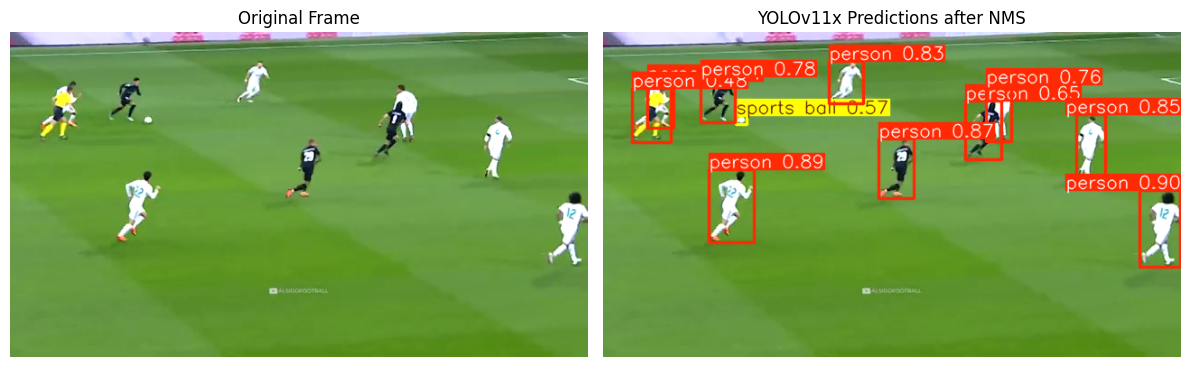

In [14]:
import matplotlib.pyplot as plt

nms_preds = model.predict(frame_rgb, conf=0.1, iou=0.8, verbose=False)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(frame_rgb)  
ax[0].set_title('Original Frame')
ax[0].axis('off')

ax[1].imshow(nms_preds[0].plot())  
ax[1].set_title('YOLOv11x Predictions after NMS')
ax[1].axis('off')

plt.tight_layout()
plt.show()


# Task 2

## DeepSORT Architecture

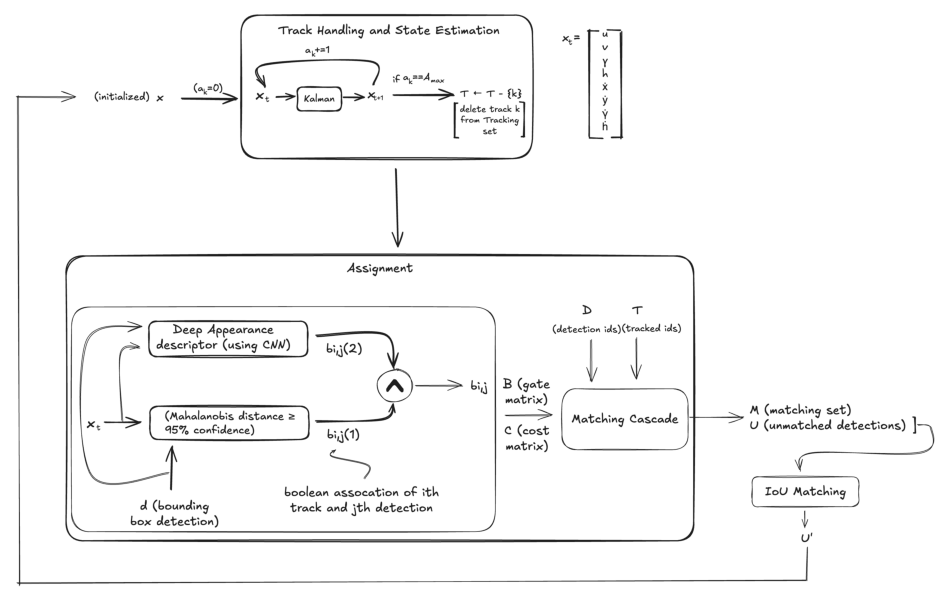

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("DeepSort.png")

plt.figure(figsize=(12, 8)) 
plt.imshow(img)
plt.axis('off')
plt.show()


## Component summary

### Bounding box prediction

It refers to any bounding box detection model such as a CNN or a conventional Computer Vision model that can detect objects present in the image and provide the bounding box parameters of the same.

### Kalman Filter

The authors use a standard Kalman filter with constant velocity motion and linear observation model, where we take the bounding coordinates (u, v, γ, h) as direct observations of the object state. The filter makes predictons of the object state for the next frame. It models a probability distribution for the object state. When a new object is identified, its initial state velocity is set to  0 and assigned a large covariance value to reflect the high uncertainty. If the tracks are not associated to a measurement after 3 frames, they are deleted.


The state vector is  

$$
\mathbf{x} = [u, v, \gamma, h, \dot{x}, \dot{y}, \dot{\gamma}, \dot{h}]^T
$$

where $u, v$ are the center coordinates, $\gamma$ is the scale (area), $r$ is the aspect ratio (assumed constant) and their respective velocities in image coordinates.

---

#### Motion Model (Prediction)

$$
\mathbf{x}_k = \mathbf{F}\mathbf{x}_{k-1} + \mathbf{w}_{k-1}, \quad 
\mathbf{w}_{k-1} \sim \mathcal{N}(0, \mathbf{Q})
$$

$$
\mathbf{F} =
\begin{bmatrix}
1 & 0 & 0 & 0 & 1 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 1 & 0 & 0 & 0 & 1 \\
0 & 0 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 1
\end{bmatrix}
$$

Predicted state:

$$
\hat{\mathbf{x}}_{k|k-1} = \mathbf{F}\hat{\mathbf{x}}_{k-1|k-1}
$$

Predicted covariance:

$$
\mathbf{P}_{k|k-1} = \mathbf{F}\mathbf{P}_{k-1|k-1}\mathbf{F}^T + \mathbf{Q}
$$

---

#### Measurement Model (Update)

$$
\mathbf{z}_k = [u, v, \gamma, r]^T, \quad
\mathbf{z}_k = \mathbf{H}\mathbf{x}_k + \mathbf{v}_k, \quad
\mathbf{v}_k \sim \mathcal{N}(0, \mathbf{R})
$$

$$
\mathbf{H} =
\begin{bmatrix}
1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 & 0 & 0
\end{bmatrix}
$$

---

#### Kalman Gain

$$
\mathbf{K}_k = \mathbf{P}_{k|k-1}\mathbf{H}^T
\left( \mathbf{H}\mathbf{P}_{k|k-1}\mathbf{H}^T + \mathbf{R} \right)^{-1}
$$

---

#### State and Covariance Update

$$
\hat{\mathbf{x}}_{k|k} = \hat{\mathbf{x}}_{k|k-1} +
\mathbf{K}_k\left( \mathbf{z}_k - \mathbf{H}\hat{\mathbf{x}}_{k|k-1} \right)
$$

$$
\mathbf{P}_{k|k} = (\mathbf{I} - \mathbf{K}_k \mathbf{H})\mathbf{P}_{k|k-1}
$$

---

#### If No Detection (Prediction Only)

$$
\hat{\mathbf{x}}_{k|k-1} = \mathbf{F}\hat{\mathbf{x}}_{k-1|k-1}, \quad
\mathbf{P}_{k|k-1} = \mathbf{F}\mathbf{P}_{k-1|k-1}\mathbf{F}^T + \mathbf{Q}
$$



### Hungarian Algorithm

After the Kalman Filter prediction step, we have a set of predicted tracks (from previous frames), each with a predicted bounding box and uncertainty and a set of new detections (from the object detector (CNN)). Now we need to associate detections to existing tracks — this is done through the Hungarian algorithm.

In DeepSORT, the rows represent existing tracks and the columns represent new detections. We already got the cost matrix through a weighted sum of the Mahalanobis distance between the predicted Kalman state and the detection box, and the cosine distance between the appearance embeddings of the track and the new detection.

The Hungarian algorithm takes this cost matrix and finds the minimum-cost one-to-one matching between tracks and detections to ensure global optimality.

### Deep Appearance Descriptor

For every new detection $\mathcal{d}_j$, DeepSORT uses a pre-trained CNN (a small, efficient re-identification network) to extract a feature vector. Each tracked object (track $k$) keeps a gallery $R_k$ of its last $L_k = 100$ appearance descriptors. For a new detection $\mathcal{d}_j$, this component compares its descriptor $r_j$ with all descriptors in the track’s gallery $R_k$ using cosine similarity.


### Cascade Matching

When two tracks are competing for the same detection (when the object is occluded for a long time), Mahalanobis distance favours the track with higer uncertainty (larger probability spread) which leads to unstable tracks and track fragmentations. To address this, the authors use matching cascade that priorities more frequently seen objects to encode the notion of probability spread in the association likelihood.
This process returns two sets - unmatched detections and matched tracks.

### IoU Matching

As a last step, the unmatched detections are run through an IoU Matching stage, same as the one used in the original SORT algorithm. This helps to to account for sudden appearance changes, e.g., due to partial occlusion with static scene geometry, and to increase robustness against erroneous initialization.

## DeepSORT Implementation

In [2]:
import torch
from torchvision import transforms
import torchreid
import numpy as np
import cv2

class TorchReIDEncoder:
    def __init__(self, device='mps'):
        self.device = device
        self.model = torchreid.models.build_model(
            name='osnet_x0_25', num_classes=1000, pretrained=True
        )
        self.model.eval().to(device)

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((256, 128)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __call__(self, frame, bboxes):
        features = []
        for box in bboxes:
            x1, y1, x2, y2 = map(int, box)
            crop = frame[y1:y2, x1:x2]
            if crop.size == 0:
                features.append(np.zeros(512, dtype=np.float32))
                continue
            tensor = self.transform(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)).unsqueeze(0).to(self.device)
            with torch.no_grad():
                feat = self.model(tensor)
            feat_np = feat.cpu().numpy().flatten().astype(np.float32)
            # Guard against zero vectors (which cause NaNs in cosine normalization)
            norm = np.linalg.norm(feat_np)
            if norm == 0 or np.isnan(norm):
                # small random epsilon vector (preserves shape)
                feat_np = np.random.normal(scale=1e-6, size=feat_np.shape).astype(np.float32)
            features.append(feat_np)
        if len(features) == 0:
            return np.zeros((0, 512), dtype=np.float32)
        return np.asarray(features, dtype=np.float32)

/Users/shashwatroy/.pyenv/versions/3.11.13/lib/python3.11/site-packages/torchreid/reid/metrics/rank.py:11: UserWarning: Cython evaluation (very fast so highly recommended) is unavailable, now use python evaluation.
  warnings.warn(


In [3]:
import cv2
import torch
import numpy as np
from ultralytics import YOLO
from deep_sort.deep_sort.tracker import Tracker
from deep_sort.deep_sort.detection import Detection
from deep_sort.deep_sort import nn_matching

if torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f"Using device: {device}")

torch_encoder = TorchReIDEncoder(device=device)

model = YOLO("yolo11n.pt")

metric = nn_matching.NearestNeighborDistanceMetric("cosine", 0.4, None)
tracker = Tracker(metric)

input_path = "video.mp4"
output_path = "output_tracked.mp4"

cap = cv2.VideoCapture(input_path)
if not cap.isOpened():
    raise ValueError(f"Cannot open video: {input_path}")

fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Video: {width}x{height} @ {fps}fps")

# This is to debug the codec issue resulting in corrupted/empty output video (temp fix)
codecs = ["avc1", "H264", "mp4v", "XVID"]
out = None
for codec in codecs:
    fourcc = cv2.VideoWriter_fourcc(*codec)
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    if out.isOpened():
        print(f"Using codec: {codec}")
        break
    out.release()

if not out.isOpened():
    raise ValueError("Failed to initialize VideoWriter with any codec")

frame_count = 0

for result in model.predict(source=input_path, stream=True, conf=0.4,verbose=False):
    frame = result.orig_img
    boxes = result.boxes.xyxy.cpu().numpy()
    confs = result.boxes.conf.cpu().numpy()
    clss = result.boxes.cls.cpu().numpy()

    bboxes_xyxy = []
    confs_list = []
    
    for bbox, conf, cls in zip(boxes, confs, clss):
        x1, y1, x2, y2 = bbox
        bboxes_xyxy.append([int(x1), int(y1), int(x2), int(y2)])
        confs_list.append(float(conf))

    if len(bboxes_xyxy) > 0:
        features = torch_encoder(frame, bboxes_xyxy)
    else:
        features = []

    detections = []
    for bbox_xyxy, conf, feat in zip(bboxes_xyxy, confs_list, features):
        x1, y1, x2, y2 = bbox_xyxy
        tlwh = [x1, y1, x2 - x1, y2 - y1]
        detections.append(Detection(tlwh, conf, feat))

    tracker.predict()
    tracker.update(detections)

    for track in tracker.tracks:
        if not track.is_confirmed() or track.time_since_update > 1:
            continue
        bbox = track.to_tlbr()
        cv2.rectangle(frame, (int(bbox[0]), int(bbox[1])),
                      (int(bbox[2]), int(bbox[3])), (0, 255, 0), 2)
        cv2.putText(frame, f"ID {track.track_id}",
                    (int(bbox[0]), int(bbox[1]) - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    out.write(frame)
    frame_count += 1
    
    if frame_count % 30 == 0:
        print(f"Processed {frame_count} frames...")

cap.release()
out.release()
cv2.destroyAllWindows()

print(f"Tracking video saved to: {output_path}")
print(f"Total frames processed: {frame_count}") # checking frame errors temp check

Using device: mps
Successfully loaded imagenet pretrained weights from "/Users/shashwatroy/.cache/torch/checkpoints/osnet_x0_25_imagenet.pth"
Video: 640x360 @ 25fps
Using codec: avc1
Processed 30 frames...
Processed 60 frames...
Processed 90 frames...
Processed 120 frames...
Processed 150 frames...
Processed 180 frames...
Processed 210 frames...
Processed 240 frames...
Processed 270 frames...
Processed 300 frames...
Processed 330 frames...
Processed 360 frames...
Processed 390 frames...
Processed 420 frames...
Processed 450 frames...
Processed 480 frames...
Processed 510 frames...
Processed 540 frames...
Processed 570 frames...
Processed 600 frames...
Processed 630 frames...
Processed 660 frames...
Processed 690 frames...
Processed 720 frames...
Processed 750 frames...
Processed 780 frames...
Processed 810 frames...
Processed 840 frames...
Processed 870 frames...
Processed 900 frames...
Processed 930 frames...
Processed 960 frames...
Processed 990 frames...
Processed 1020 frames...
Pro